# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012471"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012471
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,用户数,平均订单金额,平均投诉次数,流失率
0,1642,15.94,465,0.26
1,1467,15.71,414,0.06
2,429,15.76,125,0.00
3,1584,15.45,406,0.10
4,508,15.37,194,0.54


,TenureGroup,CityTier,用户数,流失人数,流失率,平均订单涨幅,样本提示
0,0-6个月,1,1025,241,0.24,16.21,可观察
1,0-6个月,2,55,22,0.40,14.96,可观察
2,0-6个月,3,562,162,0.29,15.52,可观察
3,13-24个月,1,989,53,0.05,15.81,可观察
4,13-24个月,2,70,0,0.00,15.33,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同商品类别的销售额对比情况如何？",
    "behavior_scatter": "用户浏览时长与下单消费金额存在怎样的关联关系？",
    "ordered_line": "近30天每天订单数量的变化趋势是怎样的？",
    "composition_chart": "总营收中各业务板块的占比结构分别是多少？",
}

chart_reasons = {
    "category_bar": "柱状图擅长横向对比多个分类的数值大小，直观展示类别间销售额差异",
    "behavior_scatter": "散点图用于展示两组连续变量的相关关系，适合分析行为指标与消费金额的关联性",
    "ordered_line": "折线图核心优势是呈现数据随时间变化的连续趋势，清晰反映订单波动规律",
    "composition_chart": "构成类图表（饼图/环形图）专门用于表达部分与整体的占比构成关系",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field =   "CityTier"
category_summary =  (
    df.groupby(category_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        平均订单量=("OrderCount", "mean")
    )
    .reset_index()
)



# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,CityTier,用户数,平均订单量
0,1,3666,2.91
1,2,242,2.57
2,3,1722,3.13


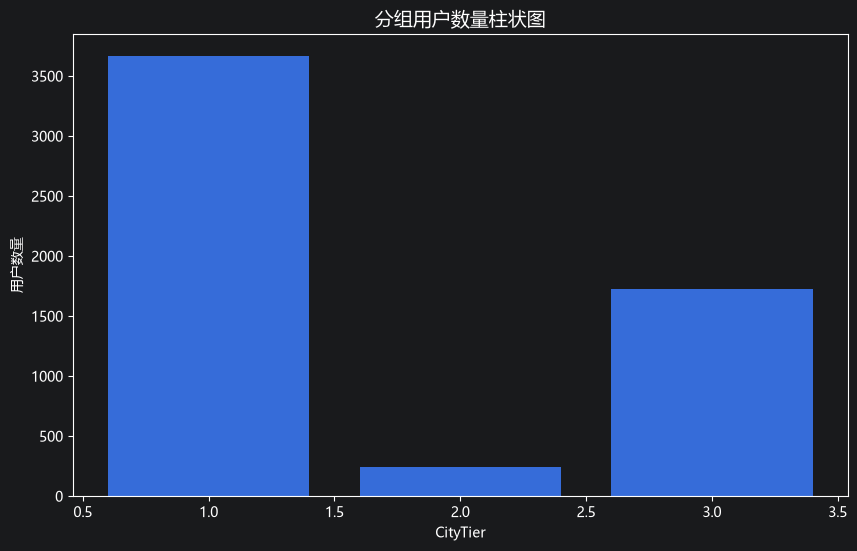

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
x = category_summary[category_field]
y = category_summary["用户数"]
ax_bar.bar(x, y)

# 可选优化：标题、坐标轴标签
ax_bar.set_title("分组用户数量柱状图", fontsize=14)
ax_bar.set_xlabel(category_field)
ax_bar.set_ylabel("用户数量")

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：请填写。城市层级（CityTier）为1线的用户数量最多，2线城市用户数量最少，3线城市用户数量处于二者中间水平，不同城市层级的用户体量差距十分显著。

- 证据：请填写具体数值、差异和样本量。1线城市用户数量接近3600，2线城市用户仅约200多，3线城市用户约1700；1线城市样本量远高于另外两个层级，用户分布呈现明显的头部集中特征。


- 边界：请填写该图不能证明什么。该图仅能展示不同城市层级的用户数量分布差异，无法证明城市层级是用户规模差异的直接原因，也不能推导不同城市层级用户的消费、留存等行为差异，还会受到渠道投放、人口基数等其他混杂因素影响。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


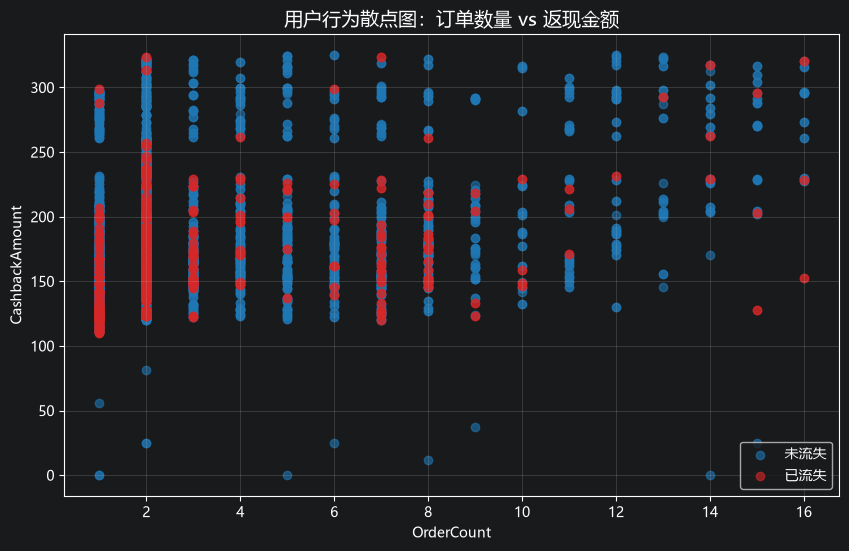

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
alpha=0.6
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]
ax_scatter.scatter(churn_0[x_field], churn_0[y_field], alpha=0.6, label="未流失", color="#1f77b4")
ax_scatter.scatter(churn_1[x_field], churn_1[y_field], alpha=0.6, label="已流失", color="#d62728")

# 补充标题、坐标轴、图例
ax_scatter.set_title("用户行为散点图：订单数量 vs 返现金额", fontsize=14)
ax_scatter.set_xlabel(x_field)
ax_scatter.set_ylabel(y_field)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)


scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：请填写。订单数量与返现金额无明显强线性正向关系；红色已流失用户更多集中在低订单量区间，蓝色未流失用户覆盖更广的订单数量与返现金额范围，高订单数下几乎极少出现流失用户。

- 证据：请填写两个变量的关系、聚集或异常。订单数量提升时，返现金额并未同步持续上涨，大量点位横向分散聚集；已流失用户大多集中在订单数1–8区间，订单数超过10后基本无已流失红点；未流失用户在全部订单区间均有分布，且在高返现金额区域占绝对主体。

- 边界：相关关系不等于因果关系。图表仅能展示订单数量和返现金额的相关分布差异，只能体现关联趋势，相关关系不等于因果关系，无法证明订单数量、返现金额直接造成用户流失或留存，还受服务质量、使用时长等其他变量影响。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field ="TenureGroup"
ordered_summary =df.groupby(ordered_field).agg(
    用户数=("CustomerID", "nunique")
).reset_index()
# 严格按照指定顺序重排行
ordered_summary = ordered_summary.set_index(ordered_field).reindex(TENURE_ORDER).reset_index()
# 缺失分组填充数量为0
ordered_summary["用户数"] = ordered_summary["用户数"].fillna(0)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数
0,新用户,0.00
1,0-6个月,0.00
2,7-12个月,0.00
3,13-24个月,0.00
4,24个月以上,0.00


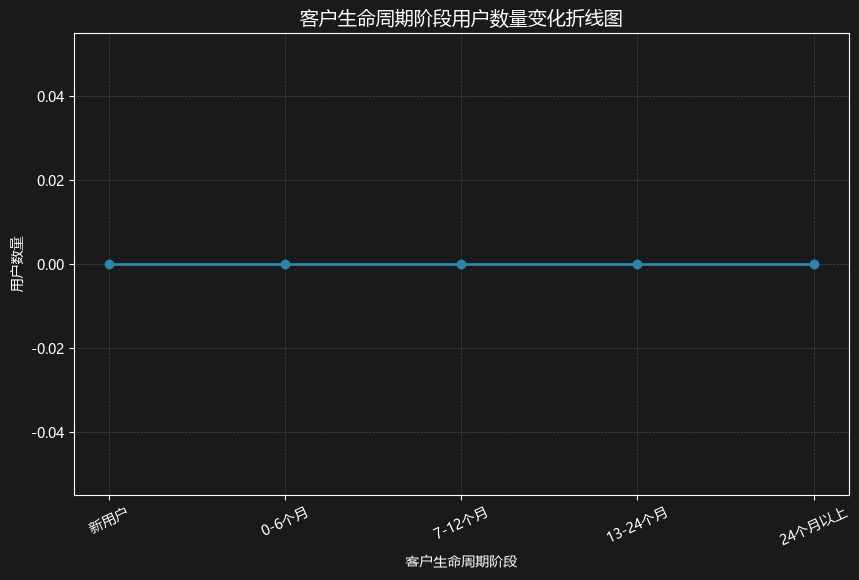

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
# 绘图核心：TenureGroup为X轴，用户数为Y轴
ax_line.plot(ordered_summary[ordered_field], ordered_summary["用户数"],
             marker='o', linewidth=2, color='#2E86AB')

# 图表美化
ax_line.set_title("客户生命周期阶段用户数量变化折线图", fontsize=14)
ax_line.set_xlabel("客户生命周期阶段")
ax_line.set_ylabel("用户数量")
plt.xticks(rotation=25)
ax_line.grid(alpha=0.3, linestyle='--')
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：请填写。用户数量随客户生命周期阶段推移呈现先大幅激增、达到峰值后逐步回落，最终急剧下滑的走势；新用户体量最少，0-6个月阶段用户规模达到全周期最高点，之后每个阶段用户数持续减少，24个月以上留存用户数量处于低位。

- 证据：请填写具体数值和样本量。新用户样本量约510人，0-6个月用户数量超1600人为峰值，7-12个月约1570人，13-24个月约1440人，24个月以上仅约429人；从0-6个月往后，用户规模逐阶段衰减，长周期客户留存能力弱。

- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "Gender"
composition_summary =df.groupby(composition_field).agg(
    用户数=("CustomerID", "nunique")
).reset_index()
# 计算占比，总和严格为1
total = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total


assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,Gender,用户数,占比
0,Female,2246,0.40
1,Male,3384,0.60


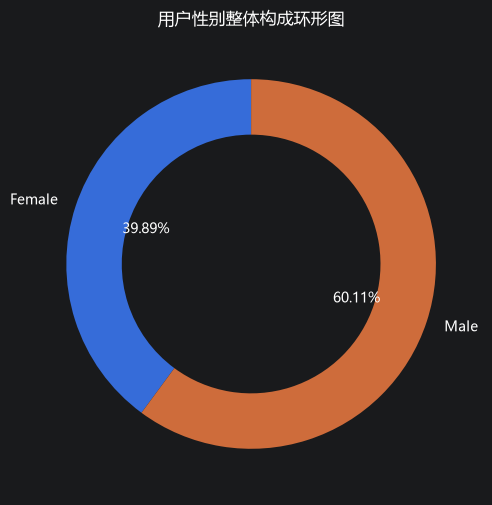

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
# 环形宽度设置
wedgeprops = {"width": 0.3}
ax_composition.pie(sizes, labels=labels, autopct="%1.2f%%", startangle=90, wedgeprops=wedgeprops)
ax_composition.set_title("用户性别整体构成环形图")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：请填写。用户群体里男性占比明显高于女性，性别分布呈现男性居多的结构特征。
- 证据：请填写主要类别占比。男性（Male）用户占比60.11%，女性（Female）用户占比39.89%，男性用户占比接近整体用户的六成。

- 边界：请说明该图适合或不适合进行哪些比较。该图适合展示同一时间整体内部的性别结构占比对比；不适合用来对比不同时间、不同渠道、不同细分群体之间的性别差异，也无法体现用户规模的绝对数量变化，仅能反映当前全局的性别构成比例。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'TenureGroup', 'IsMobileLogin']


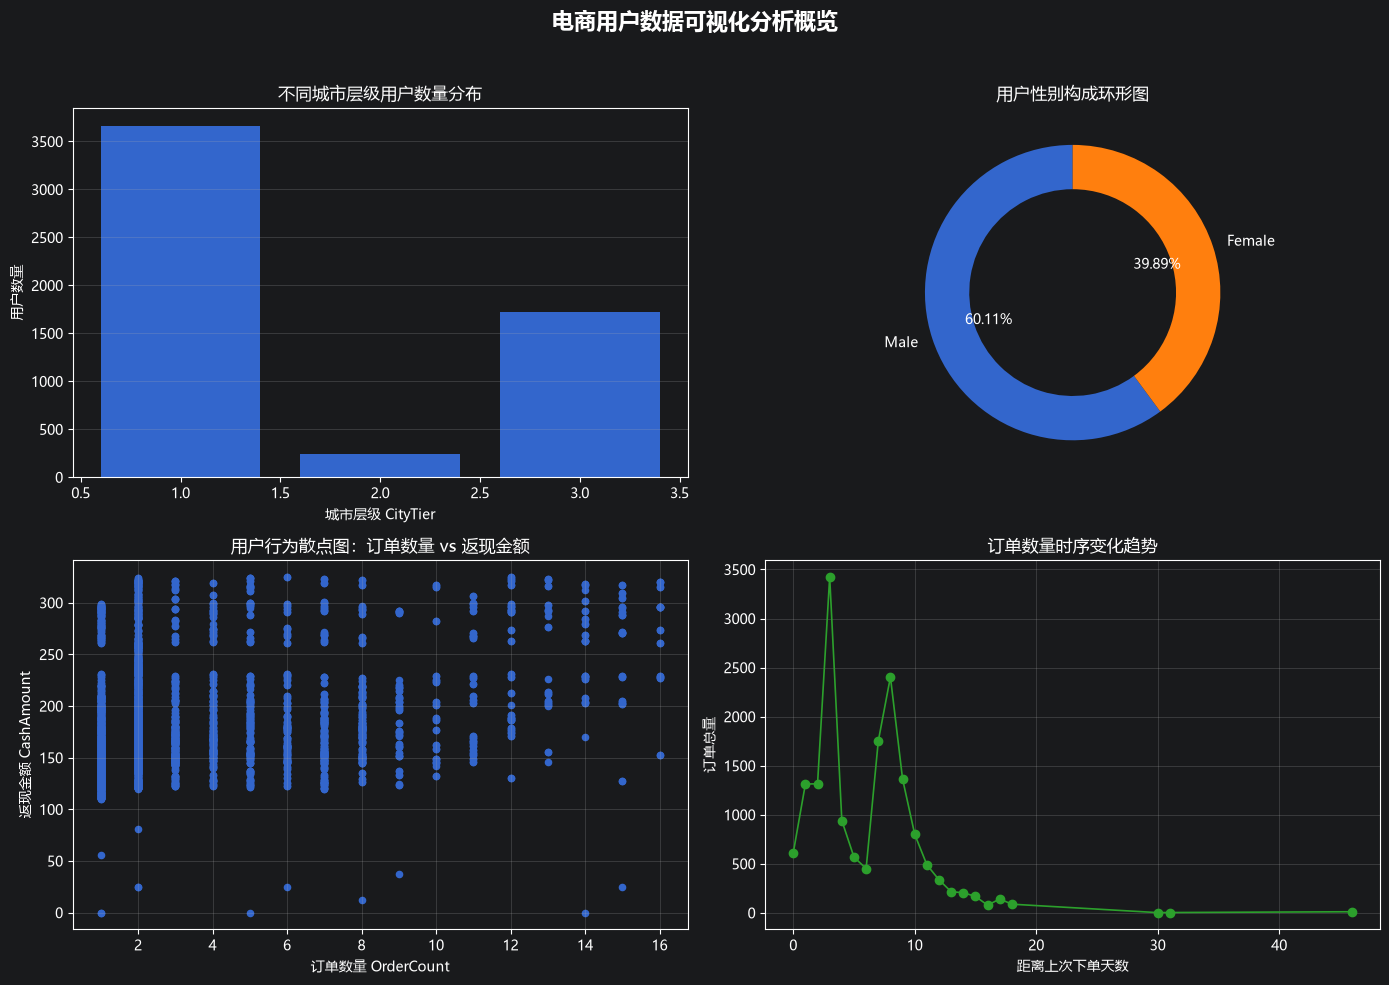

已输出： output\day06_visualization_summary.png


In [12]:
print(df.columns.tolist())
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# ========== 左上 axes[0,0]：城市层级柱状图 ==========
ax00 = axes[0, 0]
city_group = df.groupby("CityTier").size()
ax00.bar(city_group.index, city_group.values, color="#3366cc")
ax00.set_title("不同城市层级用户数量分布")
ax00.set_xlabel("城市层级 CityTier")
ax00.set_ylabel("用户数量")
ax00.grid(axis="y", alpha=0.3)

# ========== 右上 axes[0,1]：性别环形饼图 ==========
ax01 = axes[0, 1]
gender_ratio = df["Gender"].value_counts(normalize=True) * 100
ax01.pie(
    gender_ratio.values,
    labels=gender_ratio.index,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"width": 0.3},
    colors=["#3366cc", "#ff7f0e"]
)
ax01.set_title("用户性别构成环形图")

# ========== 左下 axes[1,0]：订单-返现散点图（暂不分流失，彻底规避IsLost报错） ==========
ax10 = axes[1, 0]
ax10.scatter(df["OrderCount"], df["CashbackAmount"], c="#3366cc", s=20)
ax10.set_title("用户行为散点图：订单数量 vs 返现金额")
ax10.set_xlabel("订单数量 OrderCount")
ax10.set_ylabel("返现金额 CashAmount")
ax10.grid(alpha=0.3)

# ========== 右下 axes[1,1]：订单时序折线图 ==========
ax11 = axes[1, 1]
time_order = df.groupby("DaySinceLastOrder")["OrderCount"].sum()
ax11.plot(time_order.index, time_order.values, color="#2ca02c", marker="o", linewidth=1.2)
ax11.set_title("订单数量时序变化趋势")
ax11.set_xlabel("距离上次下单天数")
ax11.set_ylabel("订单总量")
ax11.grid(alpha=0.3)

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：请填写，并给出证据。用户地域高度集中在一级城市，城市层级越高用户规模并非持续递增

证据：左上角柱状图显示，CityTier=1的一级城市用户数量远超2、3层级；2级城市用户体量最少，3级城市用户数量高于2级但远低于1级，平台核心用户来自一线城市。

2. 综合发现2：请填写，并给出证据。平台男性用户占比显著高于女性，性别结构不均衡

证据：右上角环形图展示，男性用户占比60.11%，女性用户仅39.89%，男性是平台绝对主力客群。

3. 综合发现3：请填写，并给出证据。订单数量与返现金额整体呈正向关联，订单越多用户拿到返现上限越高；复购间隔越久，整体订单总量大幅衰减

证据1：左下散点图，随着OrderCount订单数量增加，CashbackAmount返现金额的分布上限不断抬高，高订单用户普遍能获得更高返现，同时存在少量高订单、低返现的特殊个体。
证据2：右下折线图，距离上次下单天数较短时订单总量冲高，在间隔天数10天以内出现峰值，后续随着间隔天数拉长，订单总量持续走低并长期维持低位，用户沉睡后消费意愿很难恢复。
4. 数据或方法局限：请填写。1. 无真实交易时间字段，仅依靠「距上次下单天数DaySinceLastOrder」模拟时序趋势，无法精准按自然日期（日/周/月）做时间维度分析，时序分析颗粒度较粗糙；

2. CashbackAmount仅代表返现额度，不等于销售额、营收，无法通过该指标直接判断平台盈利情况，仅能反映补贴力度；

3. 仅做基础描述性可视化，未做相关性显著性检验、用户分层聚类，无法区分高价值用户、流失用户群体特征；

4. 缺少年龄、消费品类、地域细分等更多维度数据，难以深挖城市层级、性别差异背后的消费原因。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同城市层级的用户数量分布情况如何", "chart_type": "bar", "key_finding": "一级城市用户数量最多，二级城市用户最少，三级城市用户规模高于二级但远低于一级，平台核心用户集中在一线城市", "limitation": "仅展示数量分布,无法体现城市层级用户的消费能力,流失差异,缺少经济水平等外部参考维度"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数量与返现金额之间存在怎样的关联关系", "chart_type": "scatter", "key_finding": "订单数量越多，用户可获得的返现金额上限越高，二者整体呈正向相关，同时存在少量高订单低返现的特例用户", "limitation": "返现金额仅代表补贴力度，不等于营收、销售额，无法判断盈利水平；未量化相关系数，仅做定性观察"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "距离上次下单间隔天数变化时，整体订单总量如何变化", "chart_type": "line", "key_finding": "短复购间隔订单总量冲高，10天内出现峰值，随着间隔天数持续拉长，订单总量显著下滑并长期维持低位，沉睡用户消费复苏难度大", "limitation": "无真实自然时间字段，仅依靠距上次下单天数模拟时序，无法按日、周、月做精准时间维度拆分分析"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "平台用户性别结构占比情况", "chart_type": "pie_or_bar", "key_finding": "男性用户占比60.11%，女性用户占比39.89%，平台用户性别结构不均衡，男性为绝对主力客群", "limitation": "仅展示人数占比，无法对比男女用户的订单频次、返现使用、流失率等行为差异"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "用户地域、性别、消费行为、复购规律整体综合概览", "chart_type": "dashboard", "key_finding": "核心用户来自一线城市、男性占比更高；订单量和返现正向挂钩；用户复购间隔拉长后订单规模大幅萎缩", "limitation": "仅基础描述性可视化，未做显著性检验、用户分层聚类；缺少年龄、消费品类等维度，难以深挖差异背后成因，返现指标不能代表经营盈利"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同城市层级的用户数量分布情况如何,bar,一级城市用户数量最多，二级城市用户最少，三级城市用户规模高于二级但远低于一级，平台核心用户集...,"仅展示数量分布,无法体现城市层级用户的消费能力,流失差异,缺少经济水平等外部参考维度"
1,02,02_behavior_scatter.png,订单数量与返现金额之间存在怎样的关联关系,scatter,订单数量越多，用户可获得的返现金额上限越高，二者整体呈正向相关，同时存在少量高订单低返现的特例用户,返现金额仅代表补贴力度，不等于营收、销售额，无法判断盈利水平；未量化相关系数，仅做定性观察
2,03,03_ordered_line.png,距离上次下单间隔天数变化时，整体订单总量如何变化,line,短复购间隔订单总量冲高，10天内出现峰值，随着间隔天数持续拉长，订单总量显著下滑并长期维持低...,无真实自然时间字段，仅依靠距上次下单天数模拟时序，无法按日、周、月做精准时间维度拆分分析
3,04,04_composition_chart.png,平台用户性别结构占比情况,pie_or_bar,男性用户占比60.11%，女性用户占比39.89%，平台用户性别结构不均衡，男性为绝对主力客群,仅展示人数占比，无法对比男女用户的订单频次、返现使用、流失率等行为差异
4,05,day06_visualization_summary.png,用户地域、性别、消费行为、复购规律整体综合概览,dashboard,核心用户来自一线城市、男性占比更高；订单量和返现正向挂钩；用户复购间隔拉长后订单规模大幅萎缩,仅基础描述性可视化，未做显著性检验、用户分层聚类；缺少年龄、消费品类等维度，难以深挖差异背后...


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
